# Unitree G1 Humanoid: Place Apple in Bowl with PPO (V9)

This notebook trains a Unitree G1 humanoid robot to place an apple in a bowl using Proximal Policy Optimization (PPO) reinforcement learning with ManiSkill3.

## Key Challenges
- **Action masking**: 25D → 13D by zeroing left arm (right arm only)
- **Staged manipulation**: Reach → Grasp → Place → Release
- **GPU parallelization**: 512 environments running in parallel on GPU

## V9 Changes (from V8)
- V8 stuck at Stage 3 ceiling (reward ~40, success 10%) — agent grasps and holds but never releases
- Root cause 1: gamma=0.8 gives horizon ~5 steps; release needs 10-20 steps; reward 15 steps away = 0.8^15 = 0.035 (invisible)
- Root cause 2: Reward cliff during release — is_grasped flips False, reward crashes from ~3 to ~1 before success fires
- V9 fix 1: gamma=0.99, gae_lambda=0.95 — horizon ~100 steps, matches ManiSkill baselines
- V9 fix 2: ReleaseSmoothingWrapper — bridges reward valley with 4 supplementary bonuses (proximity, release, post-release, retreat)

## Setup
- Environment: `UnitreeG1PlaceAppleInBowl-v1`
- Algorithm: PPO with GAE (aligned with ManiSkill3 baseline)
- Total timesteps: 100M
- Parallel envs: 512
- Hardware target: RTX 6000 Ada (48GB)

In [1]:
# Part 1: Setup and Imports
import gymnasium as gym
import mani_skill.envs  # Register ManiSkill environments
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import mediapy as media
from tqdm import tqdm
import time
import os
from typing import Dict, Any, Tuple, Optional
from mani_skill.utils.wrappers.gymnasium import CPUGymWrapper
from mani_skill.vector.wrappers.gymnasium import ManiSkillVectorEnv

# Hardware check
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"CUDA memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("WARNING: CUDA not available, training will be slow!")

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Create output directory
os.makedirs("./results_g1", exist_ok=True)

/root/humanoid-rl-training/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/root/humanoid-rl-training/.venv/lib/python3.10/site-packages/sapien/_vulkan_tricks.py:42: UserWarning: Failed to find system libvulkan. Fallback to SAPIEN builtin libvulkan.
  warn("Failed to find system libvulkan. Fallback to SAPIEN builtin libvulkan.")


PyTorch version: 2.10.0+cu128
CUDA available: True
CUDA device: NVIDIA RTX 6000 Ada Generation
CUDA memory: 50.87 GB
Using device: cuda


## Part 3: Actor-Critic Network

Architecture:
- Separate critic network: obs_dim → 256 → 256 → 256 → 1
- Separate actor mean network: obs_dim → 256 → 256 → 256 → action_dim
- Learnable log_std initialized to -0.5
- Orthogonal initialization: sqrt(2) for hidden, 0.01*sqrt(2) for actor output, 1.0 for critic output

In [2]:
class ActorCritic(nn.Module):
    def __init__(self, obs_dim: int, action_dim: int):
        super().__init__()

        # Separate critic network: obs -> 256 -> 256 -> 256 -> 1
        self.critic = nn.Sequential(
            nn.Linear(obs_dim, 256),
            nn.Tanh(),
            nn.Linear(256, 256),
            nn.Tanh(),
            nn.Linear(256, 256),
            nn.Tanh(),
            nn.Linear(256, 1),
        )

        # Separate actor mean network: obs -> 256 -> 256 -> 256 -> action_dim
        self.actor_mean = nn.Sequential(
            nn.Linear(obs_dim, 256),
            nn.Tanh(),
            nn.Linear(256, 256),
            nn.Tanh(),
            nn.Linear(256, 256),
            nn.Tanh(),
            nn.Linear(256, action_dim),
        )

        # Learnable log standard deviation
        self.actor_logstd = nn.Parameter(torch.ones(action_dim) * -0.5)

        # Orthogonal initialization for critic hidden layers: gain sqrt(2)
        for module in self.critic:
            if isinstance(module, nn.Linear):
                nn.init.orthogonal_(module.weight, gain=np.sqrt(2))
                nn.init.constant_(module.bias, 0)
        # Critic output: gain 1.0
        nn.init.orthogonal_(self.critic[-1].weight, gain=1.0)
        nn.init.constant_(self.critic[-1].bias, 0)

        # Orthogonal initialization for actor hidden layers: gain sqrt(2)
        for module in self.actor_mean:
            if isinstance(module, nn.Linear):
                nn.init.orthogonal_(module.weight, gain=np.sqrt(2))
                nn.init.constant_(module.bias, 0)
        # Actor output: gain 0.01 * sqrt(2)
        nn.init.orthogonal_(self.actor_mean[-1].weight, gain=0.01 * np.sqrt(2))
        nn.init.constant_(self.actor_mean[-1].bias, 0)

    def get_action_and_value(self, obs: torch.Tensor, action: Optional[torch.Tensor] = None
                            ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        action_mean = self.actor_mean(obs)
        clamped_logstd = torch.clamp(self.actor_logstd, min=-2.0, max=0.5)
        std = torch.exp(clamped_logstd)
        dist = torch.distributions.Normal(action_mean, std)
        if action is None:
            action = dist.sample()
        log_prob = dist.log_prob(action).sum(dim=-1)
        entropy = dist.entropy().sum(dim=-1)
        value = self.critic(obs).squeeze(-1)
        return action, log_prob, entropy, value

    def get_value(self, obs: torch.Tensor) -> torch.Tensor:
        return self.critic(obs).squeeze(-1)

    def get_action_mean(self, obs: torch.Tensor) -> torch.Tensor:
        return self.actor_mean(obs)

# Test network
test_obs_dim = 100  # Placeholder
test_action_dim = 13  # Unitree G1 right arm only (25D masked to 13D)
test_net = ActorCritic(test_obs_dim, test_action_dim).to(device)
print("Actor-Critic network created successfully!")
print(f"Parameters: {sum(p.numel() for p in test_net.parameters()):,}")



Actor-Critic network created successfully!
Parameters: 318,491


## Part 5: GPU Vectorized Rollout Buffer

Stores rollouts from parallel environments directly on GPU.
Shape: (rollout_steps, num_envs, ...)
Computes GAE on full tensors, flattens for minibatches.

In [3]:
class RolloutBuffer:
    """Vectorized rollout buffer for GPU parallel environments."""
    
    def __init__(self, rollout_steps: int, num_envs: int, obs_dim: int, action_dim: int, device: torch.device):
        self.rollout_steps = rollout_steps
        self.num_envs = num_envs
        self.device = device
        
        # Pre-allocate tensors on GPU: shape (rollout_steps, num_envs, ...)
        self.observations = torch.zeros((rollout_steps, num_envs, obs_dim), dtype=torch.float32, device=device)
        self.actions = torch.zeros((rollout_steps, num_envs, action_dim), dtype=torch.float32, device=device)
        self.log_probs = torch.zeros((rollout_steps, num_envs), dtype=torch.float32, device=device)
        self.rewards = torch.zeros((rollout_steps, num_envs), dtype=torch.float32, device=device)
        self.values = torch.zeros((rollout_steps, num_envs), dtype=torch.float32, device=device)
        self.dones = torch.zeros((rollout_steps, num_envs), dtype=torch.float32, device=device)
        
        self.advantages = torch.zeros((rollout_steps, num_envs), dtype=torch.float32, device=device)
        self.returns = torch.zeros((rollout_steps, num_envs), dtype=torch.float32, device=device)
        
        self.step = 0
    
    def add(self, obs: torch.Tensor, action: torch.Tensor, log_prob: torch.Tensor, 
            reward: torch.Tensor, value: torch.Tensor, done: torch.Tensor):
        """Add a step of data to the buffer."""
        self.observations[self.step] = obs
        self.actions[self.step] = action
        self.log_probs[self.step] = log_prob
        self.rewards[self.step] = reward
        self.values[self.step] = value
        self.dones[self.step] = done
        self.step += 1
    
    def compute_returns_and_advantages(self, next_value: torch.Tensor, gamma: float, gae_lambda: float, final_values=None):
        """Compute GAE advantages and returns on GPU tensors."""
        last_gae = 0

        for t in reversed(range(self.rollout_steps)):
            if t == self.rollout_steps - 1:
                next_non_terminal = 1.0 - self.dones[t]
                next_value_t = next_value
            else:
                next_non_terminal = 1.0 - self.dones[t]
                next_value_t = self.values[t + 1]

            # TD error with truncation bootstrapping
            if final_values is not None:
                real_next_value = next_non_terminal * next_value_t + final_values[t]
            else:
                real_next_value = next_non_terminal * next_value_t
            delta = self.rewards[t] + gamma * real_next_value - self.values[t]

            # GAE
            last_gae = delta + gamma * gae_lambda * next_non_terminal * last_gae
            self.advantages[t] = last_gae
        
        # Returns = advantages + values
        self.returns = self.advantages + self.values
    
    def get_batches(self, batch_size: int, num_epochs: int):
        """Generate minibatches for PPO training by flattening (rollout_steps, num_envs)."""
        # Flatten (rollout_steps, num_envs) -> (rollout_steps * num_envs)
        total_size = self.rollout_steps * self.num_envs
        
        # Create flattened tensors
        flat_obs = self.observations.reshape(-1, self.observations.shape[-1])
        flat_actions = self.actions.reshape(-1, self.actions.shape[-1])
        flat_log_probs = self.log_probs.reshape(-1)
        flat_advantages = self.advantages.reshape(-1)
        flat_returns = self.returns.reshape(-1)
        flat_values = self.values.reshape(-1)
        
        # Normalize advantages
        flat_advantages = (flat_advantages - flat_advantages.mean()) / (flat_advantages.std() + 1e-8)
        
        # Generate minibatches
        indices = torch.arange(total_size, device=self.device)
        
        for epoch in range(num_epochs):
            # Shuffle indices for each epoch
            shuffled_indices = indices[torch.randperm(total_size)]
            
            for start in range(0, total_size, batch_size):
                end = min(start + batch_size, total_size)
                mb_indices = shuffled_indices[start:end]
                
                yield (
                    flat_obs[mb_indices],
                    flat_actions[mb_indices],
                    flat_log_probs[mb_indices],
                    flat_advantages[mb_indices],
                    flat_returns[mb_indices],
                    flat_values[mb_indices],
                )
    
    def reset(self):
        """Reset the buffer for next rollout."""
        self.step = 0

print("RolloutBuffer class defined!")

RolloutBuffer class defined!


## Part 6: PPO Training Function

Complete training loop with:
- GPU vectorized environments (NO CPUGymWrapper)
- Periodic evaluation on separate CPU env (10 episodes)
- Save best checkpoint
- Log metrics
- Simple value loss (no clipping)

ManiSkill3 GPU vectorized envs auto-reset. Observations may be dict with key 'obs'.
reward/terminated/truncated are tensors shape (num_envs,).

In [4]:
def flatten_obs(obs: Any) -> torch.Tensor:
    """Helper to flatten ManiSkill3 observations (dict or tensor) to tensor."""
    if isinstance(obs, dict):
        # If obs has 'obs' key, use it directly
        if 'obs' in obs:
            obs_tensor = obs['obs']
            if isinstance(obs_tensor, torch.Tensor):
                return obs_tensor.float()
            else:
                return torch.from_numpy(obs_tensor).float()
        
        # Otherwise, concatenate all tensor values in the dict
        obs_parts = []
        for key in sorted(obs.keys()):  # Sort for consistency
            val = obs[key]
            if isinstance(val, torch.Tensor):
                # Flatten if multi-dimensional
                if val.dim() > 1:
                    obs_parts.append(val.reshape(val.shape[0], -1))
                else:
                    obs_parts.append(val.unsqueeze(-1) if val.dim() == 0 else val)
            elif isinstance(val, np.ndarray):
                tensor_val = torch.from_numpy(val).float()
                if tensor_val.dim() > 1:
                    obs_parts.append(tensor_val.reshape(tensor_val.shape[0], -1))
                else:
                    obs_parts.append(tensor_val.unsqueeze(-1) if tensor_val.dim() == 0 else tensor_val)
        
        if len(obs_parts) == 0:
            raise ValueError("No valid observation tensors found in dict")
        
        return torch.cat(obs_parts, dim=-1)
    
    elif isinstance(obs, torch.Tensor):
        return obs.float()
    
    elif isinstance(obs, np.ndarray):
        return torch.from_numpy(obs.copy()).float()

    else:
        raise ValueError(f"Unsupported observation type: {type(obs)}")


class RightArmOnlyWrapper(gym.ActionWrapper):
    """Maps 13D policy actions to 25D env actions, zeroing left arm."""
    ACTIVE = [0, 2, 4, 6, 8, 10, 14, 15, 16, 20, 21, 22, 24]

    def __init__(self, env):
        super().__init__(env)
        low = env.action_space.low[..., self.ACTIVE]
        high = env.action_space.high[..., self.ACTIVE]
        self.action_space = gym.spaces.Box(low=low, high=high, dtype=np.float32)
        self._full_dim = env.action_space.shape[-1]

    def action(self, act):
        if isinstance(act, torch.Tensor):
            full = torch.zeros((*act.shape[:-1], self._full_dim), dtype=act.dtype, device=act.device)
        else:
            full = np.zeros((*act.shape[:-1], self._full_dim), dtype=np.float32)
        full[..., self.ACTIVE] = act
        return full


class ReleaseSmoothingWrapper(gym.Wrapper):
    """Adds supplementary reward to bridge the release valley.
    
    The original reward has a cliff: when agent releases apple (is_grasped -> False),
    reward drops from ~3 to ~1 before success reward (~10) fires. This wrapper
    adds small bonuses to create a gradient through the release sequence.
    """
    def __init__(self, env):
        super().__init__(env)

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)

        base_env = self.env.unwrapped
        apple_pos = base_env.apple.pose.p
        bowl_pos = base_env.bowl.pose.p
        tcp_pos = base_env.agent.right_tcp.pose.p
        finger_qpos = base_env.agent.robot.qpos[:, base_env.agent.right_finger_joint_indexes]

        goal_above_bowl = bowl_pos.clone()
        goal_above_bowl[:, 2] += 0.15
        obj_to_goal_dist = torch.linalg.norm(goal_above_bowl - apple_pos, axis=1)
        is_grasped = info["is_grasped"].float()
        not_grasped = 1.0 - is_grasped

        # 1. Extended proximity bonus (grasped + near goal = wider funnel)
        proximity_bonus = torch.clamp(1.0 - obj_to_goal_dist / 0.15, min=0.0) * 0.1 * is_grasped

        # 2. Release incentive (wider threshold: 0.08m vs original 0.025m)
        finger_openness = 1.0 - torch.tanh(torch.mean(torch.abs(finger_qpos), dim=1))
        close_to_goal = (obj_to_goal_dist < 0.08).float()
        release_bonus = close_to_goal * finger_openness * 0.2

        # 3. Post-release sustain (BRIDGES THE VALLEY)
        apple_to_bowl_dist = torch.linalg.norm(bowl_pos - apple_pos, axis=1)
        apple_near_bowl = torch.clamp(1.0 - apple_to_bowl_dist / 0.10, min=0.0)
        post_release_bonus = not_grasped * apple_near_bowl * 0.3

        # 4. Hand retreat bonus (needed for success condition)
        hand_above = torch.clamp((tcp_pos[:, 2] - bowl_pos[:, 2] - 0.125) / 0.1, min=0.0, max=1.0)
        retreat_bonus = not_grasped * apple_near_bowl * hand_above * 0.1

        reward = reward + proximity_bonus + release_bonus + post_release_bonus + retreat_bonus
        return obs, reward, terminated, truncated, info


def evaluate_policy(agent: ActorCritic, num_episodes: int = 10, 
                    max_steps: int = 100, device: torch.device = device) -> Tuple[float, float]:
    """Evaluate policy on CPU environment. Returns mean reward and success rate."""
    eval_env = gym.make(
        'UnitreeG1PlaceAppleInBowl-v1',
        num_envs=1,
        obs_mode='state',
        render_mode='rgb_array',
        reward_mode='normalized_dense'
    )
    eval_env = RightArmOnlyWrapper(eval_env)
    eval_env = ReleaseSmoothingWrapper(eval_env)
    eval_env = CPUGymWrapper(eval_env)

    episode_rewards = []
    successes = []
    
    for _ in range(num_episodes):
        obs, _ = eval_env.reset()
        episode_reward = 0
        done = False
        step_count = 0
        
        while not done and step_count < max_steps:
            # Convert obs to tensor
            obs_tensor = flatten_obs(obs).unsqueeze(0).to(device)
            
            # Get deterministic action (mean)
            with torch.no_grad():
                action = agent.get_action_mean(obs_tensor)
            
            # Step
            action_np = action.cpu().numpy()[0]
            obs, reward, terminated, truncated, info = eval_env.step(action_np)
            episode_reward += reward
            step_count += 1
            done = terminated or truncated
        
        episode_rewards.append(episode_reward)
        # Check for success in info
        if 'success' in info:
            successes.append(float(info['success']))
        elif 'episode' in info and 'success' in info['episode']:
            successes.append(float(info['episode']['success']))
    
    eval_env.close()
    
    mean_reward = np.mean(episode_rewards)
    success_rate = np.mean(successes) if len(successes) > 0 else 0.0
    
    return mean_reward, success_rate


def train_ppo(
    total_timesteps: int = 50_000_000,
    num_envs: int = 512,
    rollout_steps: int = 100,
    n_epochs: int = 8,
    num_minibatches: int = 32,
    lr: float = 3e-4,
    gamma: float = 0.8,
    gae_lambda: float = 0.9,
    clip_eps: float = 0.2,
    ent_coef: float = 0.0,
    vf_coef: float = 0.5,
    max_grad_norm: float = 0.5,
    max_episode_steps: int = 100,
    target_kl: float = 0.1,
    eval_interval: int = 50,
    save_dir: str = "./results_g1",
):
    """Main PPO training loop for Unitree G1 humanoid with GPU vectorized envs."""
    
    batch_size = (num_envs * rollout_steps) // num_minibatches

    print("=" * 60)
    print("PPO Training Configuration")
    print("=" * 60)
    print(f"Total timesteps: {total_timesteps:,}")
    print(f"Num envs: {num_envs}")
    print(f"Rollout steps: {rollout_steps}")
    print(f"Num minibatches: {num_minibatches}")
    print(f"Batch size: {batch_size}")
    print(f"Learning rate: {lr}")
    print(f"Gamma: {gamma}, GAE lambda: {gae_lambda}")
    print(f"Device: {device}")
    print("=" * 60)
    
    # Create vectorized GPU environment (NO CPUGymWrapper)
    print("\nCreating GPU vectorized environment...")
    env = gym.make(
        'UnitreeG1PlaceAppleInBowl-v1',
        num_envs=num_envs,
        obs_mode='state',
        reward_mode='normalized_dense',
        sim_config=dict(gpu_memory_config=dict(collision_stack_size=83_000_000)),
    )
    env = RightArmOnlyWrapper(env)
    env = ReleaseSmoothingWrapper(env)
    # Capture action_dim BEFORE ManiSkillVectorEnv (which may override action_space)
    action_dim = env.action_space.shape[-1]
    env = ManiSkillVectorEnv(env, num_envs=num_envs, ignore_terminations=False, record_metrics=True)

    # Get observation dimension
    obs_sample, _ = env.reset()
    obs_tensor = flatten_obs(obs_sample)
    obs_dim = obs_tensor.shape[-1]
    
    print(f"Observation dim: {obs_dim}")
    print(f"Action dim: {action_dim}")
    
    # Create agent
    agent = ActorCritic(obs_dim, action_dim).to(device)
    optimizer = optim.Adam(agent.parameters(), lr=lr, eps=1e-5)
    
    # Rollout buffer
    buffer = RolloutBuffer(rollout_steps, num_envs, obs_dim, action_dim, device)

    # Final values for truncation bootstrapping
    final_values = torch.zeros((rollout_steps, num_envs), dtype=torch.float32, device=device)
    
    # Calculate training parameters
    num_updates = total_timesteps // (num_envs * rollout_steps)
    print(f"Total updates: {num_updates}")
    
    # Tracking
    episode_rewards = []
    episode_lengths = []
    policy_losses = []
    value_losses = []
    entropies = []
    kls = []
    eval_rewards = []
    eval_success_rates = []
    
    best_eval_reward = -float('inf')
    current_episode_reward = np.zeros(num_envs)
    current_episode_length = np.zeros(num_envs)
    
    # Training loop
    global_step = 0
    start_time = time.time()
    
    print("\nStarting training...")
    
    # Reset environment
    obs, info = env.reset()
    obs = flatten_obs(obs)
    
    # Progress bar
    pbar = tqdm(total=num_updates, desc="Training")
    
    for update in range(num_updates):
        # Rollout collection
        agent.eval()
        final_values.zero_()

        for step in range(rollout_steps):
            global_step += num_envs
            
            # Get action and value (raw obs, no normalization)
            with torch.no_grad():
                action, log_prob, entropy, value = agent.get_action_and_value(obs)
            
            # Step environment
            next_obs, reward, terminated, truncated, info = env.step(action)

            # Track final values for truncation bootstrapping
            if "final_info" in info:
                done_mask = info["_final_info"]
                final_obs = flatten_obs(info["final_observation"])
                with torch.no_grad():
                    final_values[step, done_mask] = agent.get_value(final_obs[done_mask]).view(-1)

            next_obs = flatten_obs(next_obs)
            
            # Track episode stats
            current_episode_reward += reward.cpu().numpy()
            current_episode_length += 1
            
            # Check for completed episodes (ManiSkill3 auto-resets)
            done = terminated | truncated
            done_mask = done.cpu().numpy().astype(bool)
            if done_mask.any():
                episode_rewards.extend(current_episode_reward[done_mask].tolist())
                episode_lengths.extend(current_episode_length[done_mask].tolist())
                current_episode_reward[done_mask] = 0
                current_episode_length[done_mask] = 0
            
            # Store in buffer (raw obs)
            buffer.add(
                obs,
                action,
                log_prob,
                reward.float() if isinstance(reward, torch.Tensor) else torch.from_numpy(reward).float().to(device),
                value,
                done.float() if isinstance(done, torch.Tensor) else torch.from_numpy(done).float().to(device)
            )
            
            obs = next_obs
        
        # Compute returns and advantages
        with torch.no_grad():
            next_value = agent.get_value(obs)
        
        buffer.compute_returns_and_advantages(next_value, gamma, gae_lambda, final_values=final_values)
        
        # PPO update
        agent.train()
        
        update_policy_losses = []
        update_value_losses = []
        update_entropies = []
        update_kls = []
        
        kl_exceeded = False
        for batch_data in buffer.get_batches(batch_size, n_epochs):
            if kl_exceeded:
                break

            mb_obs, mb_actions, mb_old_log_probs, mb_advantages, mb_returns, mb_old_values = batch_data

            # Forward pass
            _, new_log_probs, entropy, new_values = agent.get_action_and_value(mb_obs, mb_actions)

            # Policy loss (PPO clip)
            ratio = torch.exp(new_log_probs - mb_old_log_probs)
            surr1 = ratio * mb_advantages
            surr2 = torch.clamp(ratio, 1 - clip_eps, 1 + clip_eps) * mb_advantages
            policy_loss = -torch.min(surr1, surr2).mean()

            # Value loss (simple MSE)
            value_loss = 0.5 * ((new_values - mb_returns) ** 2).mean()

            # Entropy loss
            entropy_loss = -entropy.mean()

            # Total loss
            loss = policy_loss + vf_coef * value_loss + ent_coef * entropy_loss

            # KL divergence for logging and early stopping
            with torch.no_grad():
                log_ratio = new_log_probs - mb_old_log_probs
                approx_kl = ((torch.exp(log_ratio) - 1) - log_ratio).mean()

            # Target KL early stopping
            if target_kl is not None and approx_kl.item() > target_kl:
                kl_exceeded = True
                break

            # Optimize
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(agent.parameters(), max_grad_norm)
            optimizer.step()

            update_policy_losses.append(policy_loss.item())
            update_value_losses.append(value_loss.item())
            update_entropies.append(entropy.mean().item())
            update_kls.append(approx_kl.item())
        
        if len(update_policy_losses) > 0:
            policy_losses.append(np.mean(update_policy_losses))
            value_losses.append(np.mean(update_value_losses))
            entropies.append(np.mean(update_entropies))
            kls.append(np.mean(update_kls))
        
        buffer.reset()
        
        # Evaluation every 50 updates
        if (update + 1) % eval_interval == 0 or update == num_updates - 1:
            eval_reward, success_rate = evaluate_policy(agent, num_episodes=10, device=device)
            eval_rewards.append(eval_reward)
            eval_success_rates.append(success_rate)
            
            # Save best model
            if eval_reward > best_eval_reward:
                best_eval_reward = eval_reward
                torch.save({
                    'agent': agent.state_dict(),
                }, os.path.join(save_dir, 'best_model.pt'))

            # Save checkpoint
            torch.save({
                'agent': agent.state_dict(),
                'optimizer': optimizer.state_dict(),
                'update': update,
                'global_step': global_step,
            }, os.path.join(save_dir, 'checkpoint.pt'))
        
        # Logging
        fps = int(global_step / (time.time() - start_time))
        recent_rewards = np.mean(episode_rewards[-100:]) if len(episode_rewards) > 0 else 0
        
        pbar.set_postfix({
            'fps': fps,
            'reward': f'{recent_rewards:.2f}',
            'eval_reward': f'{eval_rewards[-1]:.2f}' if len(eval_rewards) > 0 else 'N/A',
            'success': f'{eval_success_rates[-1]:.2%}' if len(eval_success_rates) > 0 else 'N/A',
        })
        pbar.update(1)
    
    pbar.close()
    env.close()
    
    print("\nTraining complete!")
    print(f"Total time: {time.time() - start_time:.2f}s")
    print(f"Best eval reward: {best_eval_reward:.2f}")
    
    # Return training history
    history = {
        'episode_rewards': episode_rewards,
        'episode_lengths': episode_lengths,
        'policy_losses': policy_losses,
        'value_losses': value_losses,
        'entropies': entropies,
        'kls': kls,
        'eval_rewards': eval_rewards,
        'eval_success_rates': eval_success_rates,
        'eval_interval': eval_interval,
        'num_updates': num_updates,
    }
    
    return agent, history

print("Training function defined!")

Training function defined!


## Part 7: Run Training (V8 — logstd clamping)

V8: Clamp actor_logstd to [-2, 0.5] to prevent entropy explosion (V7 issue).
ent_coef=0.01 kept — proved it enables release behavior at 90% success peak.

In [5]:
# Training hyperparameters (V8 — logstd clamping + ent_coef=0.01)
TOTAL_TIMESTEPS = 100_000_000
NUM_ENVS = 512
ROLLOUT_STEPS = 100
N_EPOCHS = 8
NUM_MINIBATCHES = 32
LR = 3e-4
GAMMA = 0.99
GAE_LAMBDA = 0.95
CLIP_EPS = 0.2
ENT_COEF = 0.01
VF_COEF = 0.5
MAX_GRAD_NORM = 0.5
MAX_EPISODE_STEPS = 100
TARGET_KL = 0.1

# Run training
agent, history = train_ppo(
    total_timesteps=TOTAL_TIMESTEPS,
    num_envs=NUM_ENVS,
    rollout_steps=ROLLOUT_STEPS,
    n_epochs=N_EPOCHS,
    num_minibatches=NUM_MINIBATCHES,
    lr=LR,
    gamma=GAMMA,
    gae_lambda=GAE_LAMBDA,
    clip_eps=CLIP_EPS,
    ent_coef=ENT_COEF,
    vf_coef=VF_COEF,
    max_grad_norm=MAX_GRAD_NORM,
    max_episode_steps=MAX_EPISODE_STEPS,
    target_kl=TARGET_KL,
    eval_interval=50,
    save_dir="./results_g1",
)

PPO Training Configuration
Total timesteps: 100,000,000
Num envs: 512
Rollout steps: 100
Num minibatches: 32
Batch size: 1600
Learning rate: 0.0003
Gamma: 0.99, GAE lambda: 0.95
Device: cuda

Creating GPU vectorized environment...
Download complete.
Observation dim: 74
Action dim: 13
Total updates: 1953

Starting training...


Training: 100%|██████████| 1953/1953 [3:45:56<00:00,  6.94s/it, fps=7376, reward=7.58, eval_reward=7.79, success=0.00%]


Training complete!
Total time: 13556.32s
Best eval reward: 7.84


## Part 8: Training Curves

Visualize the training progress with 2x3 subplots:
rewards, lengths, policy loss, value loss, entropy, KL

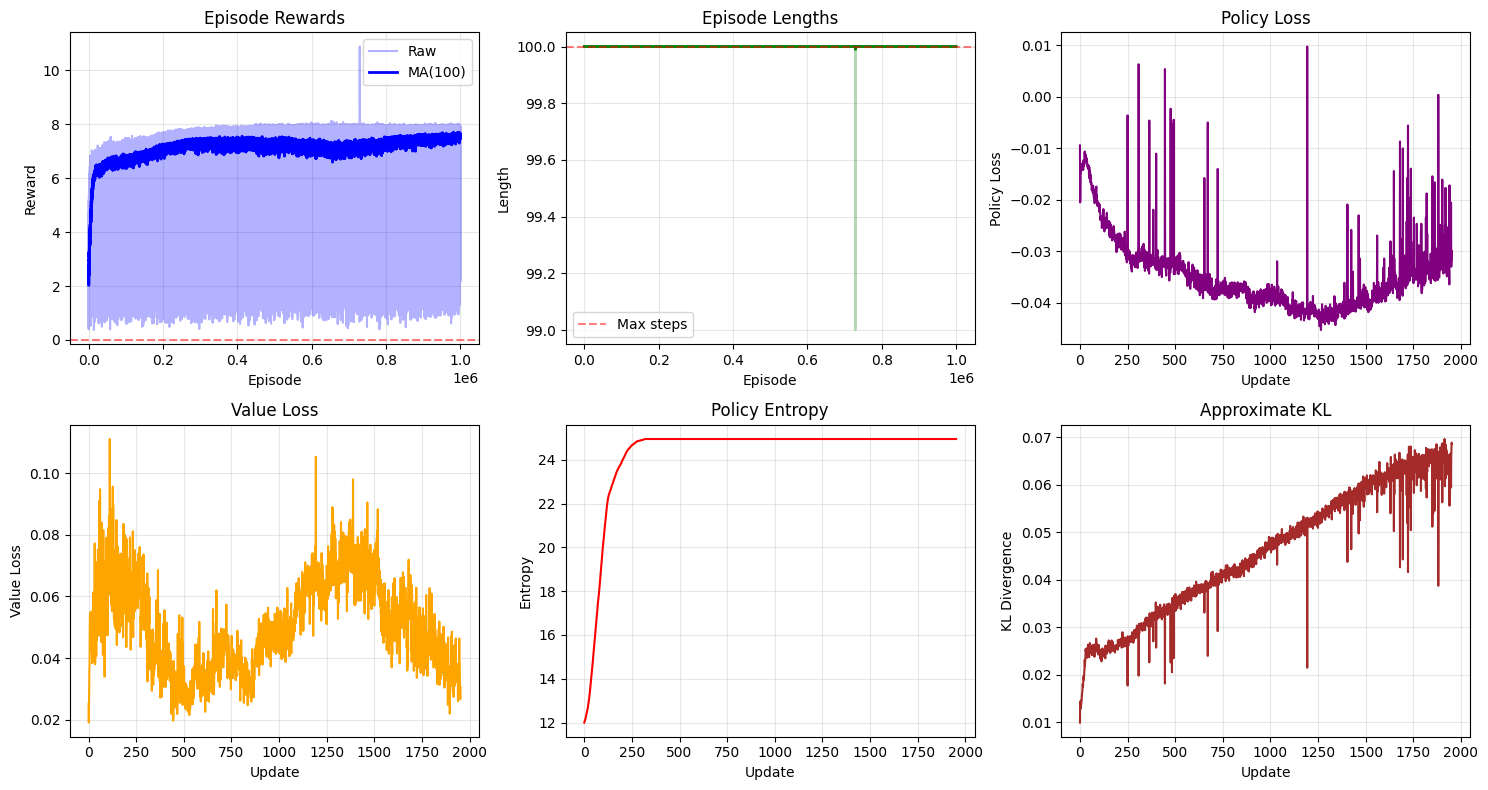

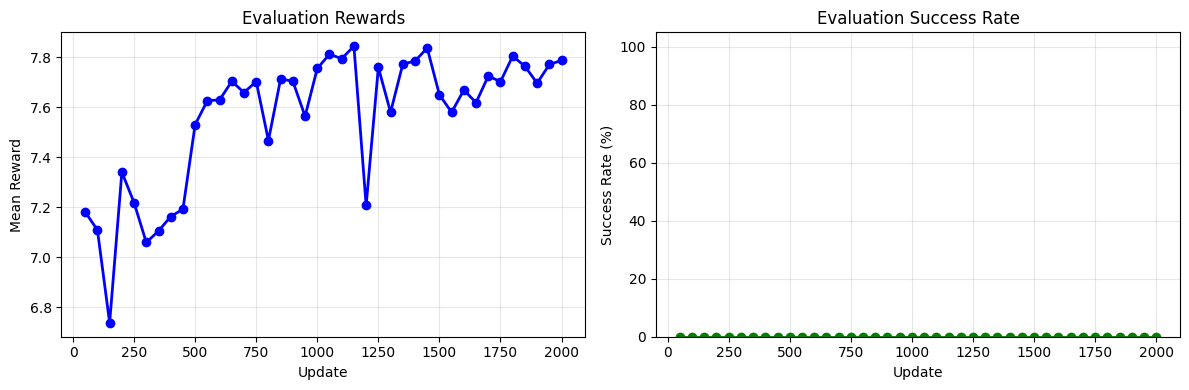

Training curves plotted!


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Episode rewards with rolling average
ax = axes[0, 0]
if len(history['episode_rewards']) > 0:
    rewards = np.array(history['episode_rewards'])
    ax.plot(rewards, alpha=0.3, color='blue', label='Raw')
    # Rolling average
    window = min(100, len(rewards) // 10) if len(rewards) > 100 else 10
    if len(rewards) > window:
        rolling = np.convolve(rewards, np.ones(window)/window, mode='valid')
        ax.plot(range(window-1, len(rewards)), rolling, color='blue', linewidth=2, label=f'MA({window})')
    ax.axhline(y=0, color='r', linestyle='--', alpha=0.5)
    ax.set_xlabel('Episode')
    ax.set_ylabel('Reward')
    ax.set_title('Episode Rewards')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Episode lengths
ax = axes[0, 1]
if len(history['episode_lengths']) > 0:
    lengths = np.array(history['episode_lengths'])
    ax.plot(lengths, alpha=0.3, color='green')
    window = min(100, len(lengths) // 10) if len(lengths) > 100 else 10
    if len(lengths) > window:
        rolling = np.convolve(lengths, np.ones(window)/window, mode='valid')
        ax.plot(range(window-1, len(lengths)), rolling, color='green', linewidth=2)
    ax.axhline(y=MAX_EPISODE_STEPS, color='r', linestyle='--', alpha=0.5, label='Max steps')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Length')
    ax.set_title('Episode Lengths')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Policy loss
ax = axes[0, 2]
ax.plot(history['policy_losses'], color='purple')
ax.set_xlabel('Update')
ax.set_ylabel('Policy Loss')
ax.set_title('Policy Loss')
ax.grid(True, alpha=0.3)

# Value loss
ax = axes[1, 0]
ax.plot(history['value_losses'], color='orange')
ax.set_xlabel('Update')
ax.set_ylabel('Value Loss')
ax.set_title('Value Loss')
ax.grid(True, alpha=0.3)

# Entropy
ax = axes[1, 1]
ax.plot(history['entropies'], color='red')
ax.set_xlabel('Update')
ax.set_ylabel('Entropy')
ax.set_title('Policy Entropy')
ax.grid(True, alpha=0.3)

# KL divergence
ax = axes[1, 2]
ax.plot(history['kls'], color='brown')
ax.set_xlabel('Update')
ax.set_ylabel('KL Divergence')
ax.set_title('Approximate KL')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("./results_g1/training_curves.png", dpi=150)
plt.show()

# Plot evaluation rewards and success rate
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

eval_updates = [(i + 1) * history['eval_interval'] for i in range(len(history['eval_rewards']))]

ax1.plot(eval_updates, history['eval_rewards'], marker='o', color='blue', linewidth=2)
ax1.set_xlabel('Update')
ax1.set_ylabel('Mean Reward')
ax1.set_title('Evaluation Rewards')
ax1.grid(True, alpha=0.3)

ax2.plot(eval_updates, [s * 100 for s in history['eval_success_rates']], marker='o', color='green', linewidth=2)
ax2.set_xlabel('Update')
ax2.set_ylabel('Success Rate (%)')
ax2.set_title('Evaluation Success Rate')
ax2.set_ylim([0, 105])
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("./results_g1/evaluation_curves.png", dpi=150)
plt.show()

print("Training curves plotted!")

## Part 9: Evaluation and Video

Load the best model and evaluate on 20 episodes using deterministic policy (action mean).
Report success rate and mean reward, record and show video of best episode.

In [5]:
# Standalone Evaluation Cell - All necessary definitions included
import gymnasium as gym
import mani_skill.envs
import torch
import torch.nn as nn
import numpy as np
from typing import Dict, Any, Tuple, Optional
from tqdm import tqdm
from mani_skill.utils.wrappers.gymnasium import CPUGymWrapper
import mediapy as media

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class ActorCritic(nn.Module):
    def __init__(self, obs_dim: int, action_dim: int):
        super().__init__()

        # Separate critic network: obs -> 256 -> 256 -> 256 -> 1
        self.critic = nn.Sequential(
            nn.Linear(obs_dim, 256),
            nn.Tanh(),
            nn.Linear(256, 256),
            nn.Tanh(),
            nn.Linear(256, 256),
            nn.Tanh(),
            nn.Linear(256, 1),
        )

        # Separate actor mean network: obs -> 256 -> 256 -> 256 -> action_dim
        self.actor_mean = nn.Sequential(
            nn.Linear(obs_dim, 256),
            nn.Tanh(),
            nn.Linear(256, 256),
            nn.Tanh(),
            nn.Linear(256, 256),
            nn.Tanh(),
            nn.Linear(256, action_dim),
        )

        # Learnable log standard deviation
        self.actor_logstd = nn.Parameter(torch.ones(action_dim) * -0.5)

        # Orthogonal initialization for critic hidden layers: gain sqrt(2)
        for module in self.critic:
            if isinstance(module, nn.Linear):
                nn.init.orthogonal_(module.weight, gain=np.sqrt(2))
                nn.init.constant_(module.bias, 0)
        # Critic output: gain 1.0
        nn.init.orthogonal_(self.critic[-1].weight, gain=1.0)
        nn.init.constant_(self.critic[-1].bias, 0)

        # Orthogonal initialization for actor hidden layers: gain sqrt(2)
        for module in self.actor_mean:
            if isinstance(module, nn.Linear):
                nn.init.orthogonal_(module.weight, gain=np.sqrt(2))
                nn.init.constant_(module.bias, 0)
        # Actor output: gain 0.01 * sqrt(2)
        nn.init.orthogonal_(self.actor_mean[-1].weight, gain=0.01 * np.sqrt(2))
        nn.init.constant_(self.actor_mean[-1].bias, 0)

    def get_action_and_value(self, obs: torch.Tensor, action: Optional[torch.Tensor] = None
                            ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        action_mean = self.actor_mean(obs)
        clamped_logstd = torch.clamp(self.actor_logstd, min=-2.0, max=0.5)
        std = torch.exp(clamped_logstd)
        dist = torch.distributions.Normal(action_mean, std)
        if action is None:
            action = dist.sample()
        log_prob = dist.log_prob(action).sum(dim=-1)
        entropy = dist.entropy().sum(dim=-1)
        value = self.critic(obs).squeeze(-1)
        return action, log_prob, entropy, value

    def get_value(self, obs: torch.Tensor) -> torch.Tensor:
        return self.critic(obs).squeeze(-1)

    def get_action_mean(self, obs: torch.Tensor) -> torch.Tensor:
        return self.actor_mean(obs)

# Test network
test_obs_dim = 100  # Placeholder
test_action_dim = 13  # Unitree G1 right arm only (25D masked to 13D)
test_net = ActorCritic(test_obs_dim, test_action_dim).to(device)
print("Actor-Critic network created successfully!")
print(f"Parameters: {sum(p.numel() for p in test_net.parameters()):,}")



def flatten_obs(obs: Any) -> torch.Tensor:
    """Helper to flatten ManiSkill3 observations (dict or tensor) to tensor."""
    if isinstance(obs, dict):
        # If obs has 'obs' key, use it directly
        if 'obs' in obs:
            obs_tensor = obs['obs']
            if isinstance(obs_tensor, torch.Tensor):
                return obs_tensor.float()
            else:
                return torch.from_numpy(obs_tensor).float()
        
        # Otherwise, concatenate all tensor values in the dict
        obs_parts = []
        for key in sorted(obs.keys()):  # Sort for consistency
            val = obs[key]
            if isinstance(val, torch.Tensor):
                # Flatten if multi-dimensional
                if val.dim() > 1:
                    obs_parts.append(val.reshape(val.shape[0], -1))
                else:
                    obs_parts.append(val.unsqueeze(-1) if val.dim() == 0 else val)
            elif isinstance(val, np.ndarray):
                tensor_val = torch.from_numpy(val).float()
                if tensor_val.dim() > 1:
                    obs_parts.append(tensor_val.reshape(tensor_val.shape[0], -1))
                else:
                    obs_parts.append(tensor_val.unsqueeze(-1) if tensor_val.dim() == 0 else tensor_val)
        
        if len(obs_parts) == 0:
            raise ValueError("No valid observation tensors found in dict")
        
        return torch.cat(obs_parts, dim=-1)
    
    elif isinstance(obs, torch.Tensor):
        return obs.float()
    
    elif isinstance(obs, np.ndarray):
        return torch.from_numpy(obs.copy()).float()

    else:
        raise ValueError(f"Unsupported observation type: {type(obs)}")


class RightArmOnlyWrapper(gym.ActionWrapper):
    """Maps 13D policy actions to 25D env actions, zeroing left arm."""
    ACTIVE = [0, 2, 4, 6, 8, 10, 14, 15, 16, 20, 21, 22, 24]

    def __init__(self, env):
        super().__init__(env)
        low = env.action_space.low[..., self.ACTIVE]
        high = env.action_space.high[..., self.ACTIVE]
        self.action_space = gym.spaces.Box(low=low, high=high, dtype=np.float32)
        self._full_dim = env.action_space.shape[-1]

    def action(self, act):
        if isinstance(act, torch.Tensor):
            full = torch.zeros((*act.shape[:-1], self._full_dim), dtype=act.dtype, device=act.device)
        else:
            full = np.zeros((*act.shape[:-1], self._full_dim), dtype=np.float32)
        full[..., self.ACTIVE] = act
        return full


class ReleaseSmoothingWrapper(gym.Wrapper):
    """Adds supplementary reward to bridge the release valley.
    
    The original reward has a cliff: when agent releases apple (is_grasped -> False),
    reward drops from ~3 to ~1 before success reward (~10) fires. This wrapper
    adds small bonuses to create a gradient through the release sequence.
    """
    def __init__(self, env):
        super().__init__(env)

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)

        base_env = self.env.unwrapped
        apple_pos = base_env.apple.pose.p
        bowl_pos = base_env.bowl.pose.p
        tcp_pos = base_env.agent.right_tcp.pose.p
        finger_qpos = base_env.agent.robot.qpos[:, base_env.agent.right_finger_joint_indexes]

        goal_above_bowl = bowl_pos.clone()
        goal_above_bowl[:, 2] += 0.15
        obj_to_goal_dist = torch.linalg.norm(goal_above_bowl - apple_pos, axis=1)
        is_grasped = info["is_grasped"].float()
        not_grasped = 1.0 - is_grasped

        # 1. Extended proximity bonus (grasped + near goal = wider funnel)
        proximity_bonus = torch.clamp(1.0 - obj_to_goal_dist / 0.15, min=0.0) * 0.1 * is_grasped

        # 2. Release incentive (wider threshold: 0.08m vs original 0.025m)
        finger_openness = 1.0 - torch.tanh(torch.mean(torch.abs(finger_qpos), dim=1))
        close_to_goal = (obj_to_goal_dist < 0.08).float()
        release_bonus = close_to_goal * finger_openness * 0.2

        # 3. Post-release sustain (BRIDGES THE VALLEY)
        apple_to_bowl_dist = torch.linalg.norm(bowl_pos - apple_pos, axis=1)
        apple_near_bowl = torch.clamp(1.0 - apple_to_bowl_dist / 0.10, min=0.0)
        post_release_bonus = not_grasped * apple_near_bowl * 0.3

        # 4. Hand retreat bonus (needed for success condition)
        hand_above = torch.clamp((tcp_pos[:, 2] - bowl_pos[:, 2] - 0.125) / 0.1, min=0.0, max=1.0)
        retreat_bonus = not_grasped * apple_near_bowl * hand_above * 0.1

        reward = reward + proximity_bonus + release_bonus + post_release_bonus + retreat_bonus
        return obs, reward, terminated, truncated, info


def evaluate_policy(agent: ActorCritic, num_episodes: int = 10, 
                    max_steps: int = 100, device: torch.device = device) -> Tuple[float, float]:
    """Evaluate policy on CPU environment. Returns mean reward and success rate."""
    eval_env = gym.make(
        'UnitreeG1PlaceAppleInBowl-v1',
        num_envs=1,
        obs_mode='state',
        render_mode='rgb_array',
        reward_mode='normalized_dense'
    )
    eval_env = RightArmOnlyWrapper(eval_env)
    eval_env = ReleaseSmoothingWrapper(eval_env)
    eval_env = CPUGymWrapper(eval_env)

    episode_rewards = []
    successes = []
    
    for _ in range(num_episodes):
        obs, _ = eval_env.reset()
        episode_reward = 0
        done = False
        step_count = 0
        
        while not done and step_count < max_steps:
            # Convert obs to tensor
            obs_tensor = flatten_obs(obs).unsqueeze(0).to(device)
            
            # Get deterministic action (mean)
            with torch.no_grad():
                action = agent.get_action_mean(obs_tensor)
            
            # Step
            action_np = action.cpu().numpy()[0]
            obs, reward, terminated, truncated, info = eval_env.step(action_np)
            episode_reward += reward
            step_count += 1
            done = terminated or truncated
        
        episode_rewards.append(episode_reward)
        # Check for success in info
        if 'success' in info:
            successes.append(float(info['success']))
        elif 'episode' in info and 'success' in info['episode']:
            successes.append(float(info['episode']['success']))
    
    eval_env.close()
    
    mean_reward = np.mean(episode_rewards)
    success_rate = np.mean(successes) if len(successes) > 0 else 0.0
    
    return mean_reward, success_rate


def train_ppo(
    total_timesteps: int = 50_000_000,
    num_envs: int = 512,
    rollout_steps: int = 100,
    n_epochs: int = 8,
    num_minibatches: int = 32,
    lr: float = 3e-4,
    gamma: float = 0.8,
    gae_lambda: float = 0.9,
    clip_eps: float = 0.2,
    ent_coef: float = 0.0,
    vf_coef: float = 0.5,
    max_grad_norm: float = 0.5,
    max_episode_steps: int = 100,
    target_kl: float = 0.1,
    eval_interval: int = 50,
    save_dir: str = "./results_g1",
):
    """Main PPO training loop for Unitree G1 humanoid with GPU vectorized envs."""
    
    batch_size = (num_envs * rollout_steps) // num_minibatches

    print("=" * 60)
    print("PPO Training Configuration")
    print("=" * 60)
    print(f"Total timesteps: {total_timesteps:,}")
    print(f"Num envs: {num_envs}")
    print(f"Rollout steps: {rollout_steps}")
    print(f"Num minibatches: {num_minibatches}")
    print(f"Batch size: {batch_size}")
    print(f"Learning rate: {lr}")
    print(f"Gamma: {gamma}, GAE lambda: {gae_lambda}")
    print(f"Device: {device}")
    print("=" * 60)
    
    # Create vectorized GPU environment (NO CPUGymWrapper)
    print("\nCreating GPU vectorized environment...")
    env = gym.make(
        'UnitreeG1PlaceAppleInBowl-v1',
        num_envs=num_envs,
        obs_mode='state',
        reward_mode='normalized_dense',
        sim_config=dict(gpu_memory_config=dict(collision_stack_size=83_000_000)),
    )
    env = RightArmOnlyWrapper(env)
    env = ReleaseSmoothingWrapper(env)
    # Capture action_dim BEFORE ManiSkillVectorEnv (which may override action_space)
    action_dim = env.action_space.shape[-1]
    env = ManiSkillVectorEnv(env, num_envs=num_envs, ignore_terminations=False, record_metrics=True)

    # Get observation dimension
    obs_sample, _ = env.reset()
    obs_tensor = flatten_obs(obs_sample)
    obs_dim = obs_tensor.shape[-1]
    
    print(f"Observation dim: {obs_dim}")
    print(f"Action dim: {action_dim}")
    
    # Create agent
    agent = ActorCritic(obs_dim, action_dim).to(device)
    optimizer = optim.Adam(agent.parameters(), lr=lr, eps=1e-5)
    
    # Rollout buffer
    buffer = RolloutBuffer(rollout_steps, num_envs, obs_dim, action_dim, device)

    # Final values for truncation bootstrapping
    final_values = torch.zeros((rollout_steps, num_envs), dtype=torch.float32, device=device)
    
    # Calculate training parameters
    num_updates = total_timesteps // (num_envs * rollout_steps)
    print(f"Total updates: {num_updates}")
    
    # Tracking
    episode_rewards = []
    episode_lengths = []
    policy_losses = []
    value_losses = []
    entropies = []
    kls = []
    eval_rewards = []
    eval_success_rates = []
    
    best_eval_reward = -float('inf')
    current_episode_reward = np.zeros(num_envs)
    current_episode_length = np.zeros(num_envs)
    
    # Training loop
    global_step = 0
    start_time = time.time()
    
    print("\nStarting training...")
    
    # Reset environment
    obs, info = env.reset()
    obs = flatten_obs(obs)
    
    # Progress bar
    pbar = tqdm(total=num_updates, desc="Training")
    
    for update in range(num_updates):
        # Rollout collection
        agent.eval()
        final_values.zero_()

        for step in range(rollout_steps):
            global_step += num_envs
            
            # Get action and value (raw obs, no normalization)
            with torch.no_grad():
                action, log_prob, entropy, value = agent.get_action_and_value(obs)
            
            # Step environment
            next_obs, reward, terminated, truncated, info = env.step(action)

            # Track final values for truncation bootstrapping
            if "final_info" in info:
                done_mask = info["_final_info"]
                final_obs = flatten_obs(info["final_observation"])
                with torch.no_grad():
                    final_values[step, done_mask] = agent.get_value(final_obs[done_mask]).view(-1)

            next_obs = flatten_obs(next_obs)
            
            # Track episode stats
            current_episode_reward += reward.cpu().numpy()
            current_episode_length += 1
            
            # Check for completed episodes (ManiSkill3 auto-resets)
            done = terminated | truncated
            done_mask = done.cpu().numpy().astype(bool)
            if done_mask.any():
                episode_rewards.extend(current_episode_reward[done_mask].tolist())
                episode_lengths.extend(current_episode_length[done_mask].tolist())
                current_episode_reward[done_mask] = 0
                current_episode_length[done_mask] = 0
            
            # Store in buffer (raw obs)
            buffer.add(
                obs,
                action,
                log_prob,
                reward.float() if isinstance(reward, torch.Tensor) else torch.from_numpy(reward).float().to(device),
                value,
                done.float() if isinstance(done, torch.Tensor) else torch.from_numpy(done).float().to(device)
            )
            
            obs = next_obs
        
        # Compute returns and advantages
        with torch.no_grad():
            next_value = agent.get_value(obs)
        
        buffer.compute_returns_and_advantages(next_value, gamma, gae_lambda, final_values=final_values)
        
        # PPO update
        agent.train()
        
        update_policy_losses = []
        update_value_losses = []
        update_entropies = []
        update_kls = []
        
        kl_exceeded = False
        for batch_data in buffer.get_batches(batch_size, n_epochs):
            if kl_exceeded:
                break

            mb_obs, mb_actions, mb_old_log_probs, mb_advantages, mb_returns, mb_old_values = batch_data

            # Forward pass
            _, new_log_probs, entropy, new_values = agent.get_action_and_value(mb_obs, mb_actions)

            # Policy loss (PPO clip)
            ratio = torch.exp(new_log_probs - mb_old_log_probs)
            surr1 = ratio * mb_advantages
            surr2 = torch.clamp(ratio, 1 - clip_eps, 1 + clip_eps) * mb_advantages
            policy_loss = -torch.min(surr1, surr2).mean()

            # Value loss (simple MSE)
            value_loss = 0.5 * ((new_values - mb_returns) ** 2).mean()

            # Entropy loss
            entropy_loss = -entropy.mean()

            # Total loss
            loss = policy_loss + vf_coef * value_loss + ent_coef * entropy_loss

            # KL divergence for logging and early stopping
            with torch.no_grad():
                log_ratio = new_log_probs - mb_old_log_probs
                approx_kl = ((torch.exp(log_ratio) - 1) - log_ratio).mean()

            # Target KL early stopping
            if target_kl is not None and approx_kl.item() > target_kl:
                kl_exceeded = True
                break

            # Optimize
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(agent.parameters(), max_grad_norm)
            optimizer.step()

            update_policy_losses.append(policy_loss.item())
            update_value_losses.append(value_loss.item())
            update_entropies.append(entropy.mean().item())
            update_kls.append(approx_kl.item())
        
        if len(update_policy_losses) > 0:
            policy_losses.append(np.mean(update_policy_losses))
            value_losses.append(np.mean(update_value_losses))
            entropies.append(np.mean(update_entropies))
            kls.append(np.mean(update_kls))
        
        buffer.reset()
        
        # Evaluation every 50 updates
        if (update + 1) % eval_interval == 0 or update == num_updates - 1:
            eval_reward, success_rate = evaluate_policy(agent, num_episodes=10, device=device)
            eval_rewards.append(eval_reward)
            eval_success_rates.append(success_rate)
            
            # Save best model
            if eval_reward > best_eval_reward:
                best_eval_reward = eval_reward
                torch.save({
                    'agent': agent.state_dict(),
                }, os.path.join(save_dir, 'best_model.pt'))

            # Save checkpoint
            torch.save({
                'agent': agent.state_dict(),
                'optimizer': optimizer.state_dict(),
                'update': update,
                'global_step': global_step,
            }, os.path.join(save_dir, 'checkpoint.pt'))
        
        # Logging
        fps = int(global_step / (time.time() - start_time))
        recent_rewards = np.mean(episode_rewards[-100:]) if len(episode_rewards) > 0 else 0
        
        pbar.set_postfix({
            'fps': fps,
            'reward': f'{recent_rewards:.2f}',
            'eval_reward': f'{eval_rewards[-1]:.2f}' if len(eval_rewards) > 0 else 'N/A',
            'success': f'{eval_success_rates[-1]:.2%}' if len(eval_success_rates) > 0 else 'N/A',
        })
        pbar.update(1)
    
    pbar.close()
    env.close()
    
    print("\nTraining complete!")
    print(f"Total time: {time.time() - start_time:.2f}s")
    print(f"Best eval reward: {best_eval_reward:.2f}")
    
    # Return training history
    history = {
        'episode_rewards': episode_rewards,
        'episode_lengths': episode_lengths,
        'policy_losses': policy_losses,
        'value_losses': value_losses,
        'entropies': entropies,
        'kls': kls,
        'eval_rewards': eval_rewards,
        'eval_success_rates': eval_success_rates,
        'eval_interval': eval_interval,
        'num_updates': num_updates,
    }
    
    return agent, history

print("Training function defined!")

def record_episode(agent: ActorCritic, max_steps: int = 100,
                   deterministic: bool = True, device: torch.device = None) -> Tuple[float, bool, list]:
    """Record a single episode and return reward, success, and frames."""
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    env = gym.make(
        'UnitreeG1PlaceAppleInBowl-v1',
        num_envs=1,
        obs_mode='state',
        render_mode='rgb_array',
        reward_mode='normalized_dense'
    )
    env = RightArmOnlyWrapper(env)
    env = ReleaseSmoothingWrapper(env)
    env = CPUGymWrapper(env)

    obs, _ = env.reset()
    frames = []
    episode_reward = 0
    done = False
    step_count = 0
    success = False
    
    while not done and step_count < max_steps:
        # Render
        frame = env.render()
        frames.append(frame)
        
        # Prepare observation
        obs_tensor = flatten_obs(obs).unsqueeze(0).to(device)
        
        # Get action (deterministic = action mean)
        with torch.no_grad():
            if deterministic:
                action = agent.get_action_mean(obs_tensor)
            else:
                action, _, _, _ = agent.get_action_and_value(obs_tensor)
        
        # Step
        action_np = action.cpu().numpy()[0]
        obs, reward, terminated, truncated, info = env.step(action_np)
        episode_reward += reward
        step_count += 1
        done = terminated or truncated
        
        if 'success' in info and info['success']:
            success = True
    
    # Capture final frame
    frames.append(env.render())
    
    env.close()
    return episode_reward, success, frames


# Load best model
print("Loading best model...")
checkpoint = torch.load("./results_g1/best_model.pt", map_location=device)

# Create new agent with same architecture
# We need to determine obs_dim and action_dim from the saved model
# For now, create a dummy env to get dimensions
temp_env = gym.make('UnitreeG1PlaceAppleInBowl-v1', num_envs=1, obs_mode='state')
temp_env = RightArmOnlyWrapper(temp_env)
temp_env = CPUGymWrapper(temp_env)
obs_sample, _ = temp_env.reset()
obs_tensor = flatten_obs(obs_sample)
obs_dim = obs_tensor.shape[-1]
# Get action_dim from checkpoint (CPUGymWrapper uses base_env action_space, not the wrapped one)
action_dim = checkpoint['agent']['actor_logstd'].shape[0]
temp_env.close()

eval_agent = ActorCritic(obs_dim, action_dim).to(device)
eval_agent.load_state_dict(checkpoint['agent'])
eval_agent.eval()

# Run evaluation episodes
print("\n" + "=" * 60)
print("Running 20 Evaluation Episodes (Deterministic Policy)")
print("=" * 60)

eval_rewards = []
eval_successes = []
best_frames = None
best_reward = -float('inf')

for i in tqdm(range(20), desc="Evaluating"):
    reward, success, frames = record_episode(eval_agent, deterministic=True, device=device)
    eval_rewards.append(reward)
    eval_successes.append(1.0 if success else 0.0)
    
    if reward > best_reward:
        best_reward = reward
        best_frames = frames

mean_reward = np.mean(eval_rewards)
success_rate = np.mean(eval_successes)
std_reward = np.std(eval_rewards)

print(f"\nEvaluation Results:")
print(f"  Mean reward: {mean_reward:.2f} ± {std_reward:.2f}")
print(f"  Success rate: {success_rate:.1%}")
print(f"  Min reward: {np.min(eval_rewards):.2f}")
print(f"  Max reward: {np.max(eval_rewards):.2f}")

# Show best episode video
if best_frames is not None and len(best_frames) > 0:
    print(f"\nBest episode (reward: {best_reward:.2f}) video:")
    media.show_video(best_frames, fps=20)

Actor-Critic network created successfully!
Parameters: 318,491
Training function defined!
Loading best model...

Running 20 Evaluation Episodes (Deterministic Policy)


Evaluating: 100%|██████████| 20/20 [00:16<00:00,  1.24it/s]



Evaluation Results:
  Mean reward: 7.45 ± 0.66
  Success rate: 0.0%
  Min reward: 4.84
  Max reward: 8.00

Best episode (reward: 8.00) video:


This browser does not support the video tag.


## Part 10: Save Results

Save the final model, statistics, and training history for future use.

In [6]:
# Save final model and results
print("=" * 60)
print("Saving Results")
print("=" * 60)

# Save final model (already saved best during training)
print(f"Best model saved at: ./results_g1/best_model.pt")

# Save training history
np.savez(
    "./results_g1/training_history.npz",
    episode_rewards=history['episode_rewards'],
    episode_lengths=history['episode_lengths'],
    policy_losses=history['policy_losses'],
    value_losses=history['value_losses'],
    entropies=history['entropies'],
    kls=history['kls'],
    eval_rewards=history['eval_rewards'],
    eval_success_rates=history['eval_success_rates'],
)
print("Training history saved: ./results_g1/training_history.npz")

# Print summary
print("\n" + "=" * 60)
print("Training Summary")
print("=" * 60)
print(f"Environment: UnitreeG1PlaceAppleInBowl-v1")
print(f"Total timesteps: {TOTAL_TIMESTEPS:,}")
print(f"Number of parallel envs: {NUM_ENVS}")
print(f"Network: Separate 256-256-256 actor/critic architecture")
print(f"\nFinal Evaluation (20 episodes, deterministic policy):")
print(f"  Mean reward: {mean_reward:.2f} ± {std_reward:.2f}")
print(f"  Success rate: {success_rate:.1%}")
print(f"\nSaved files:")
print(f"  - ./results_g1/best_model.pt")
print(f"  - ./results_g1/training_history.npz")
print(f"  - ./results_g1/training_curves.png")
print(f"  - ./results_g1/evaluation_curves.png")
print(f"  - ./results_g1/initial_state.png")
print(f"  - ./results_g1/random_policy_rewards.png")
print("=" * 60)
print("Training complete!")
print("=" * 60)

Saving Results
Best model saved at: ./results_g1/best_model.pt


NameError: name 'history' is not defined